In [ ]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("climate_data/historical/mean_seasonal_rainfall_pattern.csv")

# Create a dual-axis plot with Min, Mean, and Max temperature lines + Precipitation bars
fig, ax1 = plt.subplots(figsize=(10, 5), dpi=300)

# Bar plot for precipitation
color_bar = "#4a90e2"
ax1.set_xlabel("Month", fontsize=12)
ax1.set_ylabel("Precipitation (mm)", color=color_bar, fontsize=12)
bars = ax1.bar(df["Category"], df["Precipitation (mm)"], color=color_bar, alpha=0.6, width=0.5, label="Precipitation")
ax1.tick_params(axis="y", labelcolor=color_bar)
ax1.set_ylim(0, df["Precipitation (mm)"].max() * 1.2)

# Second y-axis for temperature
ax2 = ax1.twinx()
ax2.set_ylabel("Surface Air Temperature (°C)", color="#333333", fontsize=12)

# Plot min, mean, max temperature lines
line_mean = ax2.plot(df["Category"], df["Average Mean Surface Air Temperature (°C)"], color="#eb6834", marker="o", linewidth=2.5, label="Mean Temp")
line_max = ax2.plot(df["Category"], df["Average Maximum Surface Air Temperature (°C)"], color="#d9381e", linestyle="--", marker="^", linewidth=1.8, label="Max Temp")
line_min = ax2.plot(df["Category"], df["Average Minimum Surface Air Temperature (°C)"], color="#2b5c8f", linestyle="--", marker="v", linewidth=1.8, label="Min Temp")

# Shaded band between min and max temperature to show the thermal range clearly
ax2.fill_between(df["Category"], df["Average Minimum Surface Air Temperature (°C)"], df["Average Maximum Surface Air Temperature (°C)"], color="#eb6834", alpha=0.12, label="Min-Max Range")

ax2.tick_params(axis="y", labelcolor="#333333")
temp_min = df["Average Minimum Surface Air Temperature (°C)"].min()
temp_max = df["Average Maximum Surface Air Temperature (°C)"].max()
ax2.set_ylim(temp_min - 3, temp_max + 3)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", frameon=False, fontsize=10)

#plt.title("Monthly Precipitation and Surface Air Temperature Range", fontsize=13, fontweight="bold", pad=15)
fig.tight_layout()
plt.savefig("climate_data/historical/figures/rainfall_temperature_full_chart.png", facecolor="white")
plt.close()
print("Full temperature range chart generated successfully!")

In [6]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.ndimage import uniform_filter1d


monthly = pd.read_csv("climate_data/historical/SST_monthly.csv", parse_dates=["date"]).sort_values("date")
x = np.arange(len(monthly))
y = monthly["sst_mean"].values

slope, intercept, r, p, se = stats.linregress(x.astype(float), y.astype(float))
trend    = slope * x + intercept
rate     = slope * 12 * 10
smoothed = uniform_filter1d(y.astype(float), size=24)

print(f"Warming rate : {rate:+.3f} °C/decade")
print(f"R²           : {r**2:.3f}")
print(f"p-value      : {p:.4f}  ({'SIGNIFICANT' if p < 0.05 else 'not significant'})")


Warming rate : +0.165 °C/decade
R²           : 0.020
p-value      : 0.0018  (SIGNIFICANT)


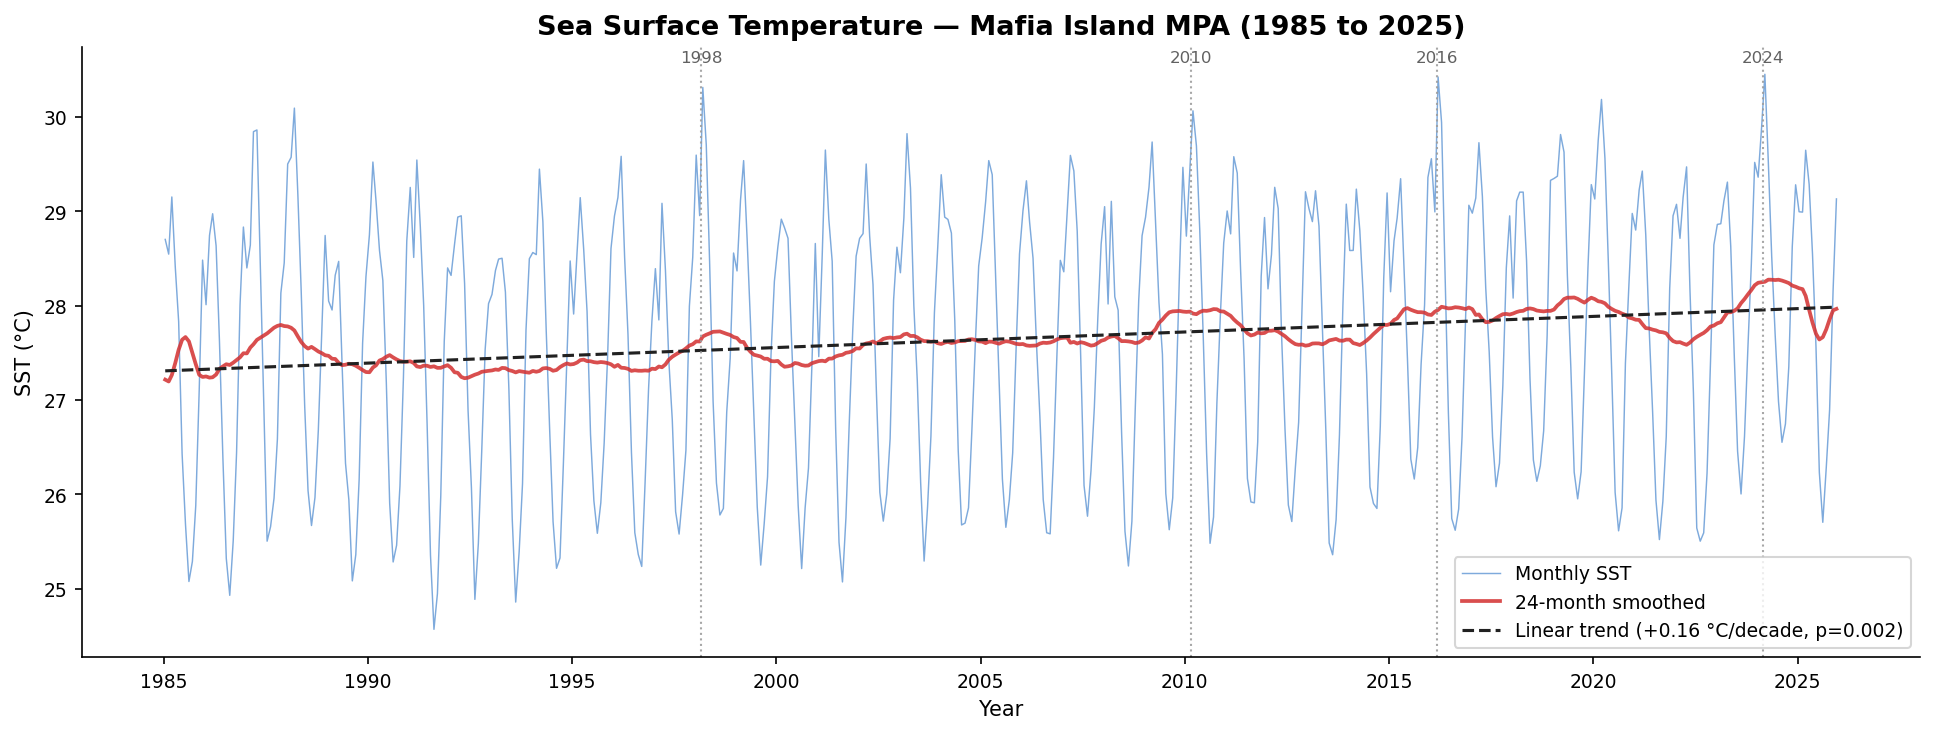

Saved to fig1_SST_longterm_trend.png


In [10]:
import matplotlib.pyplot as plt
# Study area (this is the extent location of Mafia. 
# Users can adjust this to crop the data to the AOI)
CENTRE_LAT = -7.85
CENTRE_LON =  39.82
LAT_MIN, LAT_MAX = -8.5, -7.0
LON_MIN, LON_MAX =  39.0,  40.5

# Period parameters
BASELINE_START = 1985
BASELINE_END   = 2005
RECORD_START   = 1985
RECORD_END     = 2025
CLIM_WINDOW    = 15        # ±15 days (Hobday et al. 2016)

BLEACHING_YEARS = [1998, 2010, 2016, 2024]

# Style constants
C_SST    = "#1565C0"
C_TREND  = "#212121"
C_SMOOTH = "#D32F2F"
C_ANNOT  = "#9E9E9E"
C_EARLY  = "#1976D2"
C_RECENT = "#D32F2F"

MHW_COLOURS = {
    "Moderate": "#FFC107",
    "Strong":   "#FF7043",
    "Severe":   "#D32F2F",
    "Extreme":  "#6A1B9A",
}

plt.rcParams.update({
    "figure.dpi":        150,
    "font.family":       "sans-serif",
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(monthly["date"], y,        color=C_SST,    lw=0.7, alpha=0.55, label="Monthly SST")
ax.plot(monthly["date"], smoothed, color=C_SMOOTH, lw=1.8, alpha=0.85, label="24-month smoothed")
ax.plot(monthly["date"], trend,    color=C_TREND,  lw=1.5, ls="--",
        label=f"Linear trend ({rate:+.2f} °C/decade, p={p:.3f})")

for yr in BLEACHING_YEARS:
    d = pd.Timestamp(f"{yr}-03-01")
    if monthly["date"].min() <= d <= monthly["date"].max():
        ax.axvline(d, color=C_ANNOT, lw=1.0, ls=":", alpha=0.9)
        ax.text(d, y.max() + 0.1, str(yr), fontsize=8,
                ha="center", va="bottom", color="#616161")

ax.set_title("Sea Surface Temperature — Mafia Island MPA (1985 to 2025)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("SST (°C)")
ax.legend(fontsize=9)
ax.tick_params(labelsize=9)
plt.tight_layout()
plt.savefig("climate_data/historical/figures/fig1_SST_longterm_trend.png", dpi=300, bbox_inches="tight")
plt.savefig("climate_data/historical/figures/fig1_SST_longterm_trend.svg", bbox_inches="tight")
plt.show()
print(f"Saved to {'fig1_SST_longterm_trend.png'}")


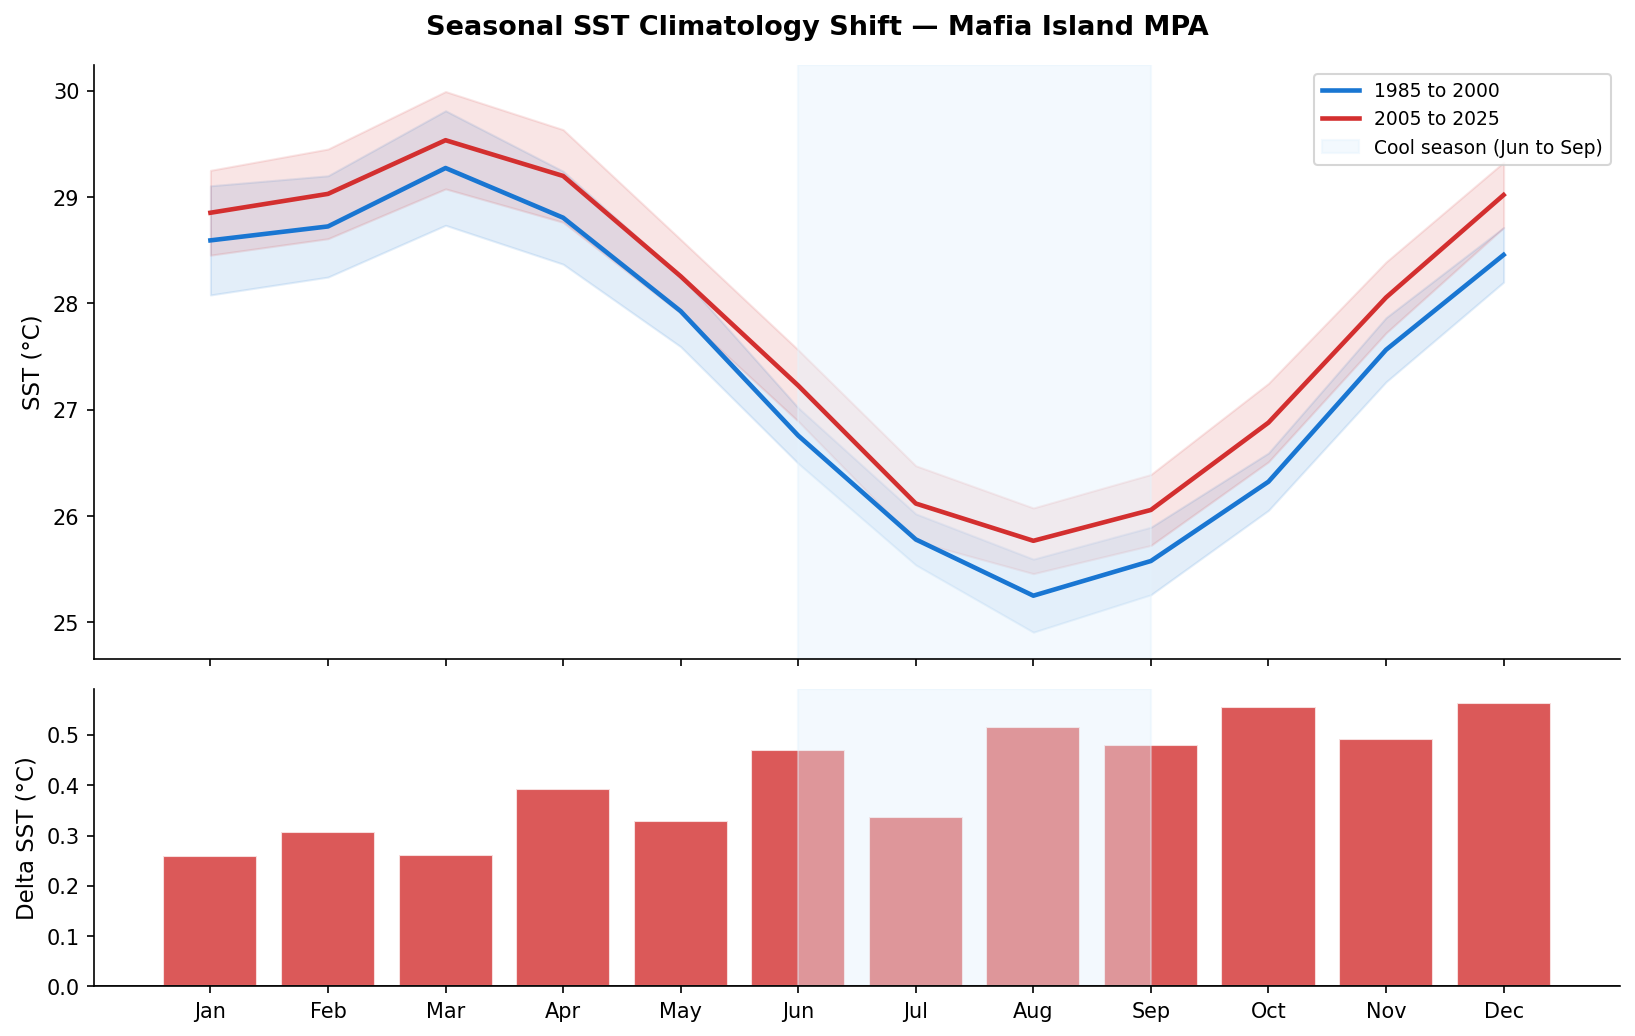

Cool season (Jun to Sep) warming shift: +0.45 °C


In [11]:
monthly = pd.read_csv("climate_data/historical/SST_monthly.csv")
early  = monthly[monthly["year"].between(1985, 2000)].groupby("month")["sst_mean"].agg(["mean", "std"])
recent = monthly[monthly["year"].between(2005, 2025)].groupby("month")["sst_mean"].agg(["mean", "std"])
diff   = recent["mean"] - early["mean"]
months = range(1, 13)
labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})
fig.suptitle("Seasonal SST Climatology Shift — Mafia Island MPA", fontsize=13, fontweight="bold")

ax1.fill_between(months, early["mean"]  - early["std"],  early["mean"]  + early["std"],  color=C_EARLY,  alpha=0.12)
ax1.fill_between(months, recent["mean"] - recent["std"], recent["mean"] + recent["std"], color=C_RECENT, alpha=0.12)
ax1.plot(months, early["mean"],  color=C_EARLY,  lw=2.2, label="1985 to 2000")
ax1.plot(months, recent["mean"], color=C_RECENT, lw=2.2, label="2005 to 2025")
ax1.axvspan(6, 9, color="#E3F2FD", alpha=0.4, label="Cool season (Jun to Sep)")
ax1.set_ylabel("SST (°C)", fontsize=11)
ax1.legend(fontsize=9)

colours = [C_RECENT if v > 0 else C_EARLY for v in diff]
ax2.bar(months, diff, color=colours, alpha=0.8, edgecolor="white")
ax2.axhline(0, color="#212121", lw=0.8)
ax2.axvspan(6, 9, color="#E3F2FD", alpha=0.4)
ax2.set_ylabel("Delta SST (°C)", fontsize=11)
ax2.set_xticks(list(months))
ax2.set_xticklabels(labels)

plt.tight_layout()
plt.savefig("climate_data/historical/figures/fig2_seasonal_climatology.png", dpi=300, bbox_inches="tight")
plt.savefig("climate_data/historical/figures/fig2_seasonal_climatology.svg", bbox_inches="tight")
plt.show()

cool_shift = diff.loc[6:9].mean()
print(f"Cool season (Jun to Sep) warming shift: {cool_shift:+.2f} °C")
